# notebook to see if my cellranger processing of K562 data is similar

In [1]:
import json
from collections import Counter

KB_PATH = "/data1/lesliec/sarthak/data/DE_danwei/k562_sc_rna_info.json"              # kb/bustools (theirs)
CR_PATH = "/data1/lesliec/sarthak/data/DE_danwei/k562_sc_rna_info_cellranger.json"  # my cellranger run

with open(KB_PATH) as f:
    kb = json.load(f)
with open(CR_PATH) as f:
    cr = json.load(f)

print(f"kb genes:         {len(kb)}")
print(f"cellranger genes: {len(cr)}")

kb genes:         18628
cellranger genes: 18674


In [2]:
# For genes present in BOTH datasets, do they land in the same split?
# split is derived only from chrom/tss, which come from the same GTF + TSS
# annotation in both scripts -- so shared genes should agree exactly.
# This is a sanity check on the annotation/split path (independent of counts).
shared = set(kb) & set(cr)
print(f"shared genes: {len(shared)}")

agree = sum(kb[g]["split"] == cr[g]["split"] for g in shared)
print(f"same split:   {agree}")
print(f"different:    {len(shared) - agree}")

# cross-tab of any disagreements (kb_split -> cr_split)
mism = Counter((kb[g]["split"], cr[g]["split"]) for g in shared if kb[g]["split"] != cr[g]["split"])
for (a, b), n in sorted(mism.items(), key=lambda x: -x[1]):
    print(f"  kb={a:<6} -> cr={b:<6}: {n}")

shared genes: 18556
same split:   18556
different:    0


In [3]:
# Per-split gene counts and membership overlap between kb and cellranger.
SPLITS = ["train", "val", "test"]

def split_sets(d):
    s = {k: set() for k in SPLITS}
    for gene, info in d.items():
        s[info["split"]].add(gene)
    return s

kb_sets = split_sets(kb)
cr_sets = split_sets(cr)

print(f"{'split':<6}{'kb':>8}{'cr':>8}{'shared':>8}{'kb-only':>9}{'cr-only':>9}{'jaccard':>9}")
for sp in SPLITS:
    a, b = kb_sets[sp], cr_sets[sp]
    inter, union = a & b, a | b
    jac = len(inter) / len(union) if union else float("nan")
    print(f"{sp:<6}{len(a):>8}{len(b):>8}{len(inter):>8}{len(a - b):>9}{len(b - a):>9}{jac:>9.3f}")

split       kb      cr  shared  kb-only  cr-only  jaccard
train    14756   14792   14695       61       97    0.989
val       2034    2038    2026        8       12    0.990
test      1838    1844    1835        3        9    0.994


shared genes: 18556
Pearson  (log-CPM): 0.9756
Spearman (log-CPM): 0.9739


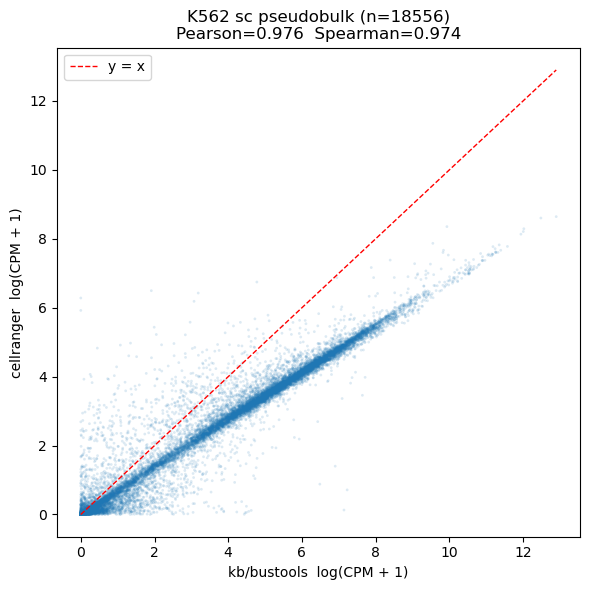

In [4]:
# Compare the count values (log-CPM) for genes shared by both datasets.
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

shared_genes = sorted(set(kb) & set(cr))
x = np.array([kb[g]["counts"] for g in shared_genes])  # kb/bustools log-CPM
y = np.array([cr[g]["counts"] for g in shared_genes])  # cellranger log-CPM

pear = pearsonr(x, y)[0]
spear = spearmanr(x, y).correlation
print(f"shared genes: {len(shared_genes)}")
print(f"Pearson  (log-CPM): {pear:.4f}")
print(f"Spearman (log-CPM): {spear:.4f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y, s=4, alpha=0.15, edgecolors="none")
lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1, label="y = x")
ax.set_xlabel("kb/bustools  log(CPM + 1)")
ax.set_ylabel("cellranger  log(CPM + 1)")
ax.set_title(f"K562 sc pseudobulk (n={len(shared_genes)})\n"
             f"Pearson={pear:.3f}  Spearman={spear:.3f}")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

Pearson  (both ln): 0.9756
Spearman (both ln): 0.9739
best-fit: y = 0.988 * x + 0.045


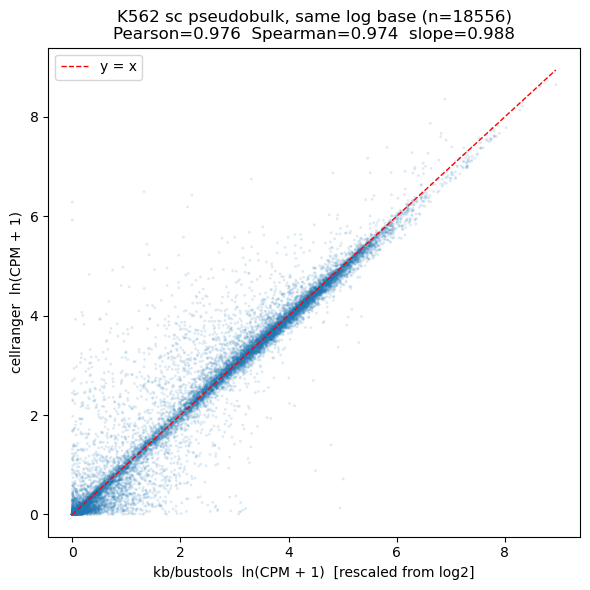

In [5]:
# The on-disk kb file (k562_sc_rna_info.json) was built with log2(CPM+1), while
# _cellranger uses natural log ln(CPM+1). Same (CPM+1) argument -> they differ by a
# constant factor only: ln(v+1) = log2(v+1) * ln(2) ~= 0.693 * log2(v+1).
# That factor is the sub-1 slope you saw. Rescale kb to natural log to match.
x_ln = x * np.log(2)   # kb: log2 -> ln

# Correlations are unchanged (Pearson/Spearman are invariant to a positive rescale),
# but the slope should now sit on the diagonal.
pear_ln = pearsonr(x_ln, y)[0]
spear_ln = spearmanr(x_ln, y).correlation
a, b = np.polyfit(x_ln, y, 1)   # best-fit line to check the slope
print(f"Pearson  (both ln): {pear_ln:.4f}")
print(f"Spearman (both ln): {spear_ln:.4f}")
print(f"best-fit: y = {a:.3f} * x + {b:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x_ln, y, s=4, alpha=0.15, edgecolors="none")
lo, hi = min(x_ln.min(), y.min()), max(x_ln.max(), y.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1, label="y = x")
ax.set_xlabel("kb/bustools  ln(CPM + 1)  [rescaled from log2]")
ax.set_ylabel("cellranger  ln(CPM + 1)")
ax.set_title(f"K562 sc pseudobulk, same log base (n={len(shared_genes)})\n"
             f"Pearson={pear_ln:.3f}  Spearman={spear_ln:.3f}  slope={a:.3f}")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

gene                 kb_ln   cr_ln   resid      len  split
ENSG00000203618       0.00    6.28    6.28    1.2kb  train
ENSG00000214736       0.00    5.92    5.92    2.4kb  train
ENSG00000243678       1.33    6.49    5.17    8.7kb  train
ENSG00000105583       0.31    4.83    4.52    1.4kb  train
ENSG00000254772       2.21    6.43    4.22   14.5kb  train
ENSG00000185883       0.74    4.92    4.17    6.5kb  train
ENSG00000161960       2.13    6.19    4.06    6.2kb  train
ENSG00000272325       1.38    5.43    4.05  113.0kb  train
ENSG00000062582       0.93    4.97    4.04    3.3kb  train
ENSG00000127774       0.18    4.07    3.89    0.9kb  train
ENSG00000203907       0.06    3.93    3.87   26.6kb  train
ENSG00000274391       0.20    4.00    3.81   84.6kb  train
ENSG00000169564       1.42    5.22    3.80    1.7kb   test
ENSG00000154710       0.90    4.60    3.70  129.4kb   test
ENSG00000122687       0.21    3.83    3.61    8.0kb  train
ENSG00000239264       0.67    4.28    3.61   29.6kb  tra

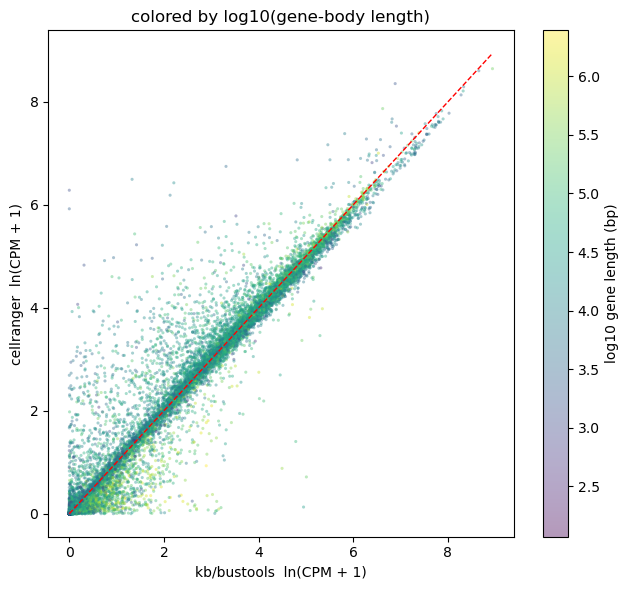

In [6]:
# Who are the high-cellranger outliers, and is the excess explained by gene length
# (a proxy for intronic content -- cellranger count includes intronic reads)?
resid = y - x_ln                       # positive => cellranger higher than kb
order = np.argsort(resid)[::-1]        # largest cellranger-excess first
glen = np.array([cr[g]["gene_end"] - cr[g]["gene_start"] for g in shared_genes])  # bp

print(f"{'gene':<18}{'kb_ln':>8}{'cr_ln':>8}{'resid':>8}{'len':>9}{'split':>7}")
for i in order[:30]:
    g = shared_genes[i]
    print(f"{g:<18}{x_ln[i]:>8.2f}{y[i]:>8.2f}{resid[i]:>8.2f}{glen[i]/1000:>7.1f}kb{cr[g]['split']:>7}")

strong = resid > 1.0                    # cellranger higher by >1 ln-unit (~e-fold)
print(f"\ngenes with cellranger-excess > 1 ln-unit: {int(strong.sum())} / {len(shared_genes)}")
print(f"Spearman(residual, gene length), all shared : {spearmanr(resid, glen).correlation:.3f}")
m = x_ln > 0                            # restrict to genes actually expressed in kb
print(f"Spearman(residual, gene length), expressed  : {spearmanr(resid[m], glen[m]).correlation:.3f}")

# color the scatter by gene length to see if the upper tail is the long genes
fig, ax = plt.subplots(figsize=(6.5, 6))
sc = ax.scatter(x_ln, y, c=np.log10(glen), s=5, alpha=0.4, cmap="viridis", edgecolors="none")
lo, hi = min(x_ln.min(), y.min()), max(x_ln.max(), y.max())
ax.plot([lo, hi], [lo, hi], "r--", lw=1)
ax.set_xlabel("kb/bustools  ln(CPM + 1)")
ax.set_ylabel("cellranger  ln(CPM + 1)")
ax.set_title("colored by log10(gene-body length)")
fig.colorbar(sc, ax=ax, label="log10 gene length (bp)")
plt.tight_layout()
plt.show()

In [7]:
# Length didn't explain the tail -> name the outlier genes to spot multimapping-prone
# families (globins, ribosomal proteins, HLA) or annotation-driven differences.
import re
GTF = "/data1/lesliec/sarthak/data/DE_danwei/gencode.v49.annotation.gtf"

def _attr(s, k):
    m = re.search(fr'{k} "([^"]+)"', s)
    return m.group(1) if m else None

id2name, id2type = {}, {}
with open(GTF) as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        f = line.split("\t")
        if f[2] != "gene":
            continue
        gid = _attr(f[8], "gene_id")
        if gid is None:
            continue
        gid = gid.split(".")[0]
        id2name[gid] = _attr(f[8], "gene_name")
        id2type[gid] = _attr(f[8], "gene_type")

print(f"{'gene':<18}{'name':<14}{'kb_ln':>7}{'cr_ln':>7}{'resid':>7}{'len':>8}")
for i in order[:30]:
    g = shared_genes[i]
    print(f"{g:<18}{str(id2name.get(g, '?')):<14}{x_ln[i]:>7.2f}{y[i]:>7.2f}{resid[i]:>7.2f}{glen[i] / 1000:>6.1f}kb")

# is the excess tied to expression level rather than length?
mean_expr = (x_ln + y) / 2
print(f"\nSpearman(residual, mean expression): {spearmanr(resid, mean_expr).correlation:.3f}")

gene              name            kb_ln  cr_ln  resid     len
ENSG00000203618   GP1BB            0.00   6.28   6.28   1.2kb
ENSG00000214736   TOMM6            0.00   5.92   5.92   2.4kb
ENSG00000243678   NME2             1.33   6.49   5.17   8.7kb
ENSG00000105583   WDR83OS          0.31   4.83   4.52   1.4kb
ENSG00000254772   EEF1G            2.21   6.43   4.22  14.5kb
ENSG00000185883   ATP6V0C          0.74   4.92   4.17   6.5kb
ENSG00000161960   EIF4A1           2.13   6.19   4.06   6.2kb
ENSG00000272325   NUDT3            1.38   5.43   4.05 113.0kb
ENSG00000062582   MRPS24           0.93   4.97   4.04   3.3kb
ENSG00000127774   EMC6             0.18   4.07   3.89   0.9kb
ENSG00000203907   OOEP             0.06   3.93   3.87  26.6kb
ENSG00000274391   TPTE             0.20   4.00   3.81  84.6kb
ENSG00000169564   PCBP1            1.42   5.22   3.80   1.7kb
ENSG00000154710   RABGEF1          0.90   4.60   3.70 129.4kb
ENSG00000122687   MRM2             0.21   3.83   3.61   8.0kb
ENSG0000